<h1><span style="background-color: yellow; color: blue; padding: 5px; border-radius: 5px;">Customer Sentiment Analysis - Flipkart</span></h1>

<h1><span style="background-color: white; color: black; padding: 5px; border-radius: 5px;">Objective</span></h1>

As a Data Analyst at Amazon, you have been tasked with gauging customer sentiment towards the iPhone 15 128GB model. The primary goal of this project is to analyze public perception and evaluate customer reactions by performing sentiment analysis on product reviews posted by users. By extracting and processing customer reviews, you will derive insights about the overall sentiment (positive or negative) surrounding the product, which can be useful for decision-making, improving customer experience, and identifying key areas for product improvement.

<h1><span style="background-color: white; color: black; padding: 5px; border-radius: 5px;">Tasks: Performed in this Project</span></h1>

<h1><span style="background-color: blue; color: white; padding: 5px; border-radius: 5px;">1. Data Collection (Web Scraping)</span></h1>

**Tool:** Selenium and BeautifulSoup  

**Task:** Scrape at least 300 customer reviews from Flipkart's product page for the iPhone 15 128GB model. Each review should include:

- **Username:** The name of the reviewer.
- **Rating:** The rating provided by the user (1 to 5 stars).  
- **Review Text:** The content of the customer's review, which may contain valuable information regarding their experience with the product.  

---

#### **Steps:**

1. **Set Up Selenium:**  
   - Automate browser interactions and navigate to Flipkart’s product page for the iPhone 15 128GB, and extract the reviews.  

2. **Use BeautifulSoup:**  
   - Parse the HTML of the reviews and extract the relevant details:  
     - Username
     - Rating  
     - Review Text

3. **Handle Pagination:**  
   - Ensure that the scraper handles pagination to retrieve reviews from multiple pages if necessary.

In [16]:
# Import the necessary librariess
import requests
import time
import pandas as pd
from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager

<h1><span style="background-color: blue; color: white; padding: 5px; border-radius: 5px;">2. Data Cleaning and Processing</span></h1>

**Tool:** Pandas  

**Task:** Clean and preprocess the scraped data for analysis.  

#### **Steps:**

1. **Remove Duplicates:**  
   - Eliminate any duplicate reviews to ensure data quality.  

2. **Handle Missing Values:**  
   - Address missing or incomplete data, such as missing review text or rating, by either:  
     - Removing rows with missing values.  
     - Filling in missing values if applicable.  

3. **Text Preprocessing:**  
   - **Convert to Lowercase:** Standardize the text by converting all review text to lowercase.  
   - **Remove Irrelevant Characters:** Strip out special characters, punctuation, and extra spaces.

In [33]:
# Creating empty lists to store the user data like Name, Reviews & Rating
Names = []
Reviews = []
Ratings = []

# Assign the url of the flipkart website and use selenium to scrape data
url = """https://www.flipkart.com/apple-iphone-15-pink-128-gb/product-reviews/itm7579ed94ca647?pid=MOBGTAGPNMZA5PU5"""
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()))
driver.get(url)

while len(Names) < 320:

    time.sleep(2)
    soup = BeautifulSoup(driver.page_source, "html.parser")

    # Scrape names
    temp_names = soup.find_all("p", {"class": "zJ1ZGa ZDi3w2"})
    for name in temp_names:
        Names.append(name.text)

    # Scrape reviews
    temp_reviews = soup.find_all("div", {"class": "G4PxIA"})
    for review in temp_reviews:
        Reviews.append(review.text)

    # Scrape ratings
    temp_ratings = soup.find_all("div", class_ = "MKiFS6 ojKpP6")
    for ratings in temp_ratings:
        Ratings.append(ratings.text)

    # Try to click the "Next" button
    try:
        next_button = driver.find_element(By.XPATH, "//span[text()='Next']")
        next_button.click()
        time.sleep(5)
    except:
        break

# Combine data into a DataFrame
min_len = min(len(Names), len(Reviews), len(Ratings))
Names = Names[:min_len]
Reviews = Reviews[:min_len]
Ratings = Ratings[:min_len]

data = pd.DataFrame({
    "Name": Names,
    "Review": Reviews,
    "Rating": Ratings
})

# Save to a CSV files
data.to_csv("flipkart_iphone_reviews_pink.csv", index=False)
print("Done!")

Done!


In [34]:
# Assigning the scraped dataset(a csv file) to a dataframe
new_data = pd.read_csv('flipkart_iphone_reviews_pink.csv')
new_data

,Name,Review,Rating
0,Arunji Govindaraju,Awesome product very happy to hold this. Bette...,5
1,Thakur Surya Pratap Singh,Awesome 😎READ MORE,5
2,Rishabh Jha,Awesome 🔥🔥☺️READ MORE,5
3,Flipkart Customer,Awesome photography experience. Battery backup...,5
4,Nikhil Kumar,Switch from OnePlus to iPhone I am stunned wit...,5
...,...,...,...
315,Gajendra Singh,Very goodREAD MORE,5
316,Aryan Gupta,Awesome 👌👌👌👌👌READ MORE,5
317,Anil Kumar,Nice product but poor packaging from flipkartR...,5
318,Mr. Kadir,I phone 15 amezing phone 📱 i am very happy for...,5


In [35]:
# Checking the basic info of the dataframe
new_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Name    320 non-null    object
 1   Review  320 non-null    object
 2   Rating  320 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 7.6+ KB


In [36]:
# Checking value counts of the Name column
new_data['Name'].value_counts()

Name
Flipkart Customer            31
Thakur Surya Pratap Singh     1
Rishabh  Jha                  1
Yash                          1
Soni  Nirav                   1
                             ..
Sheetla Prasad Maurya         1
Rahul Shedge                  1
mohit  yadav                  1
Sandip Mandal                 1
Chandan Deka                  1
Name: count, Length: 290, dtype: int64

In [37]:
# Dropping the duplicates from the dataframe
new_data = new_data.copy()
new_data = new_data.drop_duplicates()
new_data

,Name,Review,Rating
0,Arunji Govindaraju,Awesome product very happy to hold this. Bette...,5
1,Thakur Surya Pratap Singh,Awesome 😎READ MORE,5
2,Rishabh Jha,Awesome 🔥🔥☺️READ MORE,5
3,Flipkart Customer,Awesome photography experience. Battery backup...,5
4,Nikhil Kumar,Switch from OnePlus to iPhone I am stunned wit...,5
...,...,...,...
315,Gajendra Singh,Very goodREAD MORE,5
316,Aryan Gupta,Awesome 👌👌👌👌👌READ MORE,5
317,Anil Kumar,Nice product but poor packaging from flipkartR...,5
318,Mr. Kadir,I phone 15 amezing phone 📱 i am very happy for...,5


In [38]:
# Converting the Name column data into Title Case
new_data['Name'] = new_data['Name'].str.title()
new_data.head()

,Name,Review,Rating
0,Arunji Govindaraju,Awesome product very happy to hold this. Bette...,5
1,Thakur Surya Pratap Singh,Awesome 😎READ MORE,5
2,Rishabh Jha,Awesome 🔥🔥☺️READ MORE,5
3,Flipkart Customer,Awesome photography experience. Battery backup...,5
4,Nikhil Kumar,Switch from OnePlus to iPhone I am stunned wit...,5


In [45]:
# Cleaning data of Review column by removing unwanted characters/part of string and converting to lowercase
new_data['Review'] = new_data['Review'].str.lower().str.replace("read more", "", regex=False)
new_data.head()

,Name,Review,Rating
0,Arunji Govindaraju,awesome product very happy to hold this. bette...,5
1,Thakur Surya Pratap Singh,awesome 😎,5
2,Rishabh Jha,awesome 🔥🔥☺️,5
3,Flipkart Customer,awesome photography experience. battery backup...,5
4,Nikhil Kumar,switch from oneplus to iphone i am stunned wit...,5


<h1><span style="background-color: blue; color: white; padding: 5px; border-radius: 5px;">3. Sentiment Analysis</span></h1>

**Tool:** TextBlob  

**Task:** Analyze the sentiment of each review to classify them as either positive or negative.  

#### **Steps:**

1. **Perform Sentiment Analysis: Use TextBlob to perform sentiment analysis on the review text**  
   - TextBlob will provide a polarity score between -1 (negative) and +1 (positive), as well as a subjectivity score.    

2. **Define Sentiment Thresholds:**
   - **Positive Sentiment:** Polarity score >= 0.1
   - **Negative Sentiment:** Polarity score < 0.1

3. **Store Sentiment Classification:**  
   - Store the sentiment classification for each review in the dataset.

In [47]:
# Importing libraries for Sentimental analysis of review sentences 
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize
from nltk.tokenize import word_tokenize
from textblob import TextBlob
import string

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Shiva\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Shiva\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Shiva\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Shiva\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [48]:
# Store the sentiment classification for each review in the dataset.
new_data["Reviews_t"] = new_data['Review'].apply(sent_tokenize)
new_data

,Name,Review,Rating,Reviews_t
0,Arunji Govindaraju,awesome product very happy to hold this. bette...,5,"[awesome product very happy to hold this., bet..."
1,Thakur Surya Pratap Singh,awesome 😎,5,[awesome 😎]
2,Rishabh Jha,awesome 🔥🔥☺️,5,[awesome 🔥🔥☺️]
3,Flipkart Customer,awesome photography experience. battery backup...,5,"[awesome photography experience., battery back..."
4,Nikhil Kumar,switch from oneplus to iphone i am stunned wit...,5,[switch from oneplus to iphone i am stunned wi...
...,...,...,...,...
315,Gajendra Singh,very good,5,[very good]
316,Aryan Gupta,awesome 👌👌👌👌👌,5,[awesome 👌👌👌👌👌]
317,Anil Kumar,nice product but poor packaging from flipkart,5,[nice product but poor packaging from flipkart]
318,Mr. Kadir,i phone 15 amezing phone 📱 i am very happy for...,5,[i phone 15 amezing phone 📱 i am very happy fo...


In [49]:
# Importing mean from statistics for basic statistics
from statistics import mean

# To assign Polarity to the Reviews_t column creating functions
def get_polarity(sentences):
    return [TextBlob(sentence).sentiment.polarity for sentence in sentences]

# Calling get_polarity function on the Reviews_t column to assign polarity
new_data['Polarity'] = new_data['Reviews_t'].apply(get_polarity)

# To calculate the average polarity of each review (Average of polarity for each sentences in a review), created a function
def calculate_average_polarity(polarities):
    return mean(polarities) if polarities else 0

# Calling calculate_average_polarity function on the Polarity column to assign the average polarity for each review
new_data['Average_Polarity'] = new_data['Polarity'].apply(calculate_average_polarity)
new_data['Average_Polarity'] = new_data['Average_Polarity'].round(2)
new_data.head(10)

,Name,Review,Rating,Reviews_t,Polarity,Average_Polarity
0,Arunji Govindaraju,awesome product very happy to hold this. bette...,5,"[awesome product very happy to hold this., bet...","[1.0, 0.5, 0.45555555555555555]",0.65
1,Thakur Surya Pratap Singh,awesome 😎,5,[awesome 😎],[1.0],1.00
2,Rishabh Jha,awesome 🔥🔥☺️,5,[awesome 🔥🔥☺️],[1.0],1.00
3,Flipkart Customer,awesome photography experience. battery backup...,5,"[awesome photography experience., battery back...","[1.0, 0.7, 0.5]",0.73
4,Nikhil Kumar,switch from oneplus to iphone i am stunned wit...,5,[switch from oneplus to iphone i am stunned wi...,"[0.0, 1.0]",0.50
5,Ajin V,high quality camera😍,5,[high quality camera😍],[0.16],0.16
6,Mousam Guha Roy,very nice,4,[very nice],[0.78],0.78
7,Akshay Meena,"so beautiful, so elegant, just a vowww😍❤️",5,"[so beautiful, so elegant, just a vowww😍❤️]",[0.675],0.68
8,Prithivi Boruah,camera quality is improved loving it,5,[camera quality is improved loving it],[0.6],0.60
9,Flipkart Customer,using this iphone 15 from 1month and it has be...,5,[using this iphone 15 from 1month and it has b...,[1.0],1.00


In [103]:
# Function to assign the Class to the Polarity
#def sentiment_class(polarity):
    #if polarity >= 0.1:
       # return 'positive'
  #  else:
     #   return 'negative'
def sentiment_class(polarity):
    if polarity > 0.75:
        return 'extremely positive'
    elif 0 < polarity >= 0.1:
        return 'positive'
    elif polarity == 0:
        return 'neutral'
    elif -0.5 <= polarity < 0.1:
        return 'negative'
    else:
        return 'extremely negative'

new_data['Sentiment_Class'] = new_data['Average_Polarity'].apply(sentiment_class)

In [104]:
new_data.head()

,Name,Review,Rating,Reviews_t,Polarity,Average_Polarity,Sentiment_Class
0,Arunji Govindaraju,awesome product very happy to hold this. bette...,5,"[awesome product very happy to hold this., bet...","[1.0, 0.5, 0.45555555555555555]",0.65,positive
1,Thakur Surya Pratap Singh,awesome 😎,5,[awesome 😎],[1.0],1.00,extremely positive
2,Rishabh Jha,awesome 🔥🔥☺️,5,[awesome 🔥🔥☺️],[1.0],1.00,extremely positive
3,Flipkart Customer,awesome photography experience. battery backup...,5,"[awesome photography experience., battery back...","[1.0, 0.7, 0.5]",0.73,positive
4,Nikhil Kumar,switch from oneplus to iphone i am stunned wit...,5,[switch from oneplus to iphone i am stunned wi...,"[0.0, 1.0]",0.50,positive


In [105]:
# Calculates and prints the overall average polarity score of the entire dataset of reviews
polarity_score = new_data['Average_Polarity'].mean().round(2)
print(f'Average Polarity Score : {polarity_score}')
#if polarity_score >= 0.1: Giving error in word cloud with this assumption
       # print('The Average Polarity Score is Positive')
#else:
    #print('The Average Polarity Score is Negative')
if polarity_score > 0.75:
        print('The Average Polarity Score is Extremely Positive')
elif 0 < polarity_score >= 0.1:
    print('The Average Polarity Score is Positive')
elif polarity_score == 0:
    print('The Average Polarity Score is Neutral')
elif -0.5 <= polarity_score < 0.1:
    print('The Average Polarity Score is Negative')
else:
    print('The Average Polarity Score is Extremely Negative')

Average Polarity Score : 0.47
The Average Polarity Score is Positive


<h1><span style="background-color: blue; color: white; padding: 5px; border-radius: 5px;">4. Data Analysis and Insights</span></h1>

**Tool:** Pandas and Matplotlib/Seaborn for visualization  

**Task:** Perform an analysis on the sentiment of reviews and extract actionable insights.  

#### **Steps:**

1. **Sentiment Distribution:**
   - Calculate the overall distribution of positive and negative sentiments for the 300 reviews.    

2. **Average Rating vs Sentiment:**
   - Analyze if there is any correlation between the numeric ratings (1-5 stars) and sentiment polarity. Do higher ratings correspond with more positive sentiments?

3. **Word Cloud:**
    - Create a word cloud to identify the most frequently mentioned words in the positive and negative reviews.

4. **Review Length Analysis:**  
   - Investigate if longer reviews are associated with more detailed sentiments, either positive or negative.

In [61]:
# Importing libraries for visualisation
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


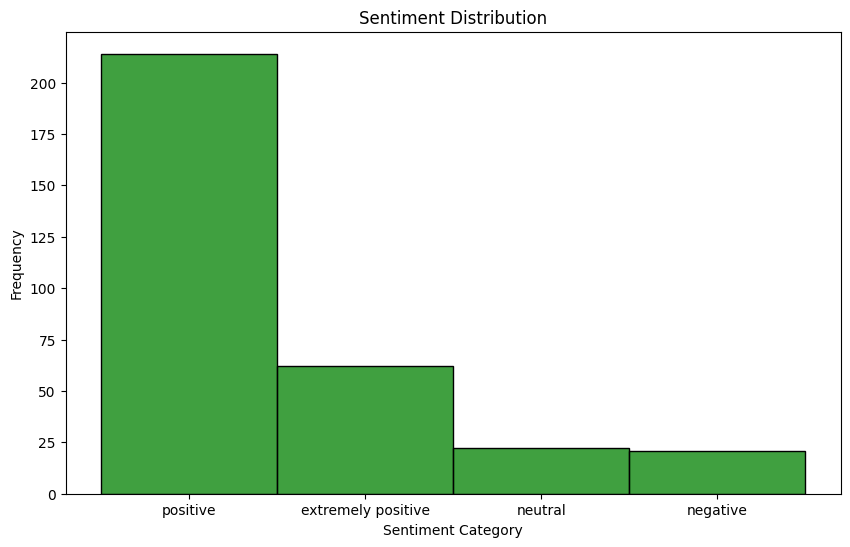

In [106]:
# Plots figure for Sentiment Distribution based on Sentiment Category
plt.figure(figsize=(10, 6))
sns.histplot(x=new_data.Sentiment_Class, color='green')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment Category')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.show()

<u>**Sentiment Distribution**</u>

This bar chart displays the distribution of sentiment categories within a dataset. The x-axis represents different sentiment categories, while the y-axis represents the frequency of occurrences in each category. The categories include:

1. **Positive**: This category has the highest frequency, with over 200 instances.
2. **Extremely Positive**: This category comes next, with a significantly lower frequency compared to "Positive".
3. **Neutral**: This category has a much smaller frequency than the previous two.
4. **Negative**: This category has the lowest frequency.

The chart indicates a clear bias towards positive sentiments in the dataset, with "Positive" being the dominant category, followed by "Extremely Positive". Neutral and negative sentiments are comparatively rare.

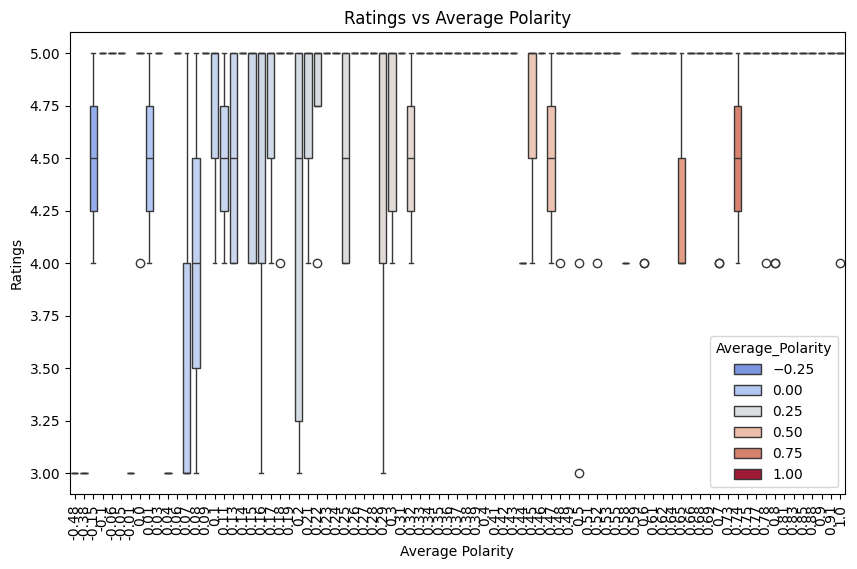

In [107]:
# Plotting ratings vs average polarity
plt.figure(figsize=(10, 6))
sns.boxplot(x='Average_Polarity', y='Rating', data = new_data, hue = 'Average_Polarity', palette='coolwarm')
plt.title('Ratings vs Average Polarity')
plt.xlabel('Average Polarity')
plt.ylabel('Ratings')
plt.xticks(rotation=90)
plt.show()

Based on the *Ratings vs Average Polarity* boxplot, there is a **general positive relationship** between star ratings and sentiment polarity, but the correlation is not perfect. Here are the key observations:

**1. Higher ratings tend to show higher sentiment polarity**

 - Reviews with **4 and 5 stars** consistently display **higher polarity scores**, clustering in the light-orange to red ranges (0.25, 0.50, 0.75, 1.00).
 - This indicates that users giving higher ratings typically express **more positive written sentiment**.

**2. Lower ratings correspond with lower polarity values**

**3-star reviews**, and occasionally **4-star reviews**, contain more **neutral or slightly negative polarity values** (blue/light-blue areas such as −0.25 or 0.00).
  - The presence of low-polity reviews at lower rating levels is expected and supports the idea that lower satisfaction corresponds with more negative language.

**3. Some variability exists within each rating level**

 - Even among **5-star reviews**, a few points show neutral or slightly negative polarity (values near 0 or below).
 - This suggests some users rate the product highly but still mention minor issues or write less emotional reviews.
 - Similarly, some **4-star reviews** show a wide range of polarity scores, implying that users express mixed or balanced opinions.

**4. Overall correlation: Positive but not perfect**

 - The general trend shows that as **Average Polarity increases**, the **Ratings also trend upward**.
 - The boxplots become more “warm colored” (orange/red) as ratings rise, visually confirming this pattern.
 - However, sentiment polarity cannot fully explain rating behavior—reviewers sometimes give high ratings with neutral text or lower ratings with moderately positive wording.

**<u>Conclusion</u>**

**Higher star ratings generally correspond to more positive sentiment polarity.**
The chart indicates a **positive correlation** between the numeric scores and the emotional tone of the review text. While there are exceptions due to variability in how users express feedback, the overall pattern supports the idea that:

- **More positive written sentiment → Higher review rating**
- **More negative or neutral sentiment → Lower review rating**

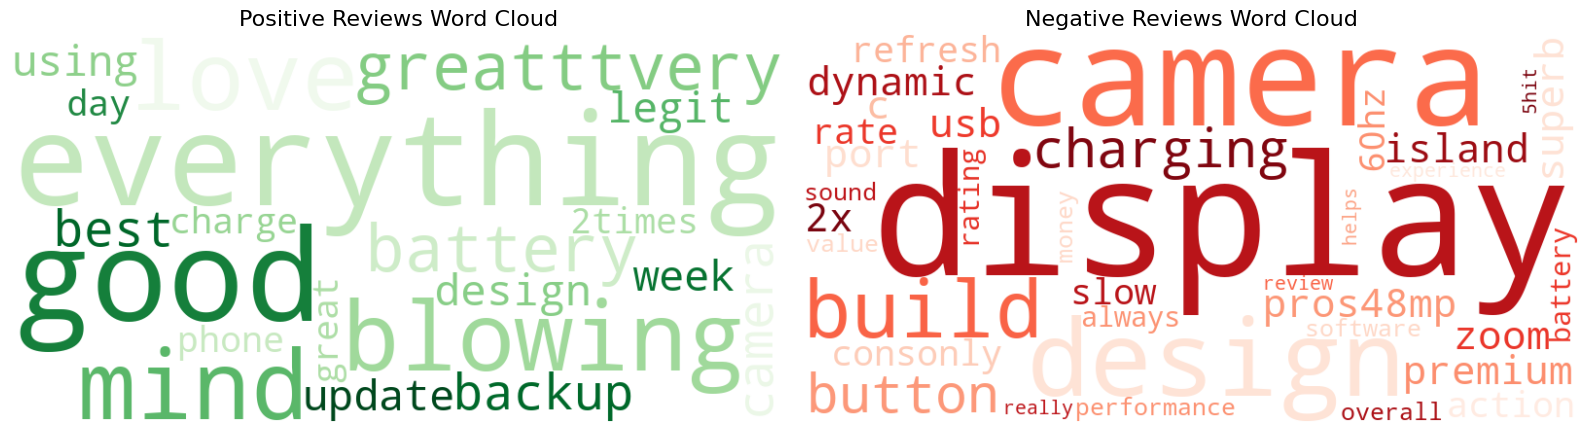

In [111]:
from wordcloud import WordCloud

positive_reviews = []
negative_reviews = []

# Differenciate the positive & negative reviews separately
#for i in range(len(new_data)):
    #if new_data.iloc[i]['Sentiment_Class'] == 'positive':
        #positive_reviews.append(new_data.iloc[i]['Review'])
   # elif new_data.iloc[i]['Sentiment_Class'] == 'negative':
        #negative_reviews.append(new_data.iloc[i]['Review'])
for i in range(len(new_data)):
    if new_data.iloc[i]['Sentiment_Class'] == 'positive' or new_data.iloc[i]['Sentiment_Class'] == 'extremely positive':
        positive_reviews.append(new_data.iloc[i]['Review'])
    elif new_data.iloc[i]['Sentiment_Class'] == 'negative' or new_data.iloc[i]['Sentiment_Class'] == 'extremely negative':
        negative_reviews.append(new_data.iloc[i]['Review'])

# Assigning random positive and negative reviews to create a cloud map
pos = positive_reviews[230]
neg = negative_reviews[1]

# Create word clouds for positive and negative reviews
positive_wordcloud = WordCloud(width=800, height=400, background_color="white", colormap="Greens").generate(pos)
negative_wordcloud = WordCloud(width=800, height=400, background_color="white", colormap="Reds").generate(neg)

# Ploting the word clouds
plt.figure(figsize=(16, 8))

# Positive reviews word cloud
plt.subplot(1, 2, 1)
plt.imshow(positive_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Positive Reviews Word Cloud", fontsize=16)

# Negative reviews word cloud
plt.subplot(1, 2, 2)
plt.imshow(negative_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Negative Reviews Word Cloud", fontsize=16)

plt.tight_layout()
plt.show()

<u> **Word Cloud Description:** </u>

The above image displays two word clouds generated from customer reviews:

1. **Positive Reviews Word Cloud** (left side, green color):  
   Highlights frequently mentioned positive words like **"greattt," "very good," "best,"** and **"mindblowing,"** indicating attributes appreciated by customers.

2. **Negative Reviews Word Cloud** (right side, red color):  
   Features prominent negative terms such as **"slow," "shit," "camera,"** and **"charging,"** representing commonly cited issues or complaints.

This visualization provides insights into key themes in customer sentiment.

In [112]:
# Calculate the length of the sentences by calculating the number of words in the review sentence
new_data['Review_Length'] = new_data['Review'].apply(lambda x: len(x.split()))

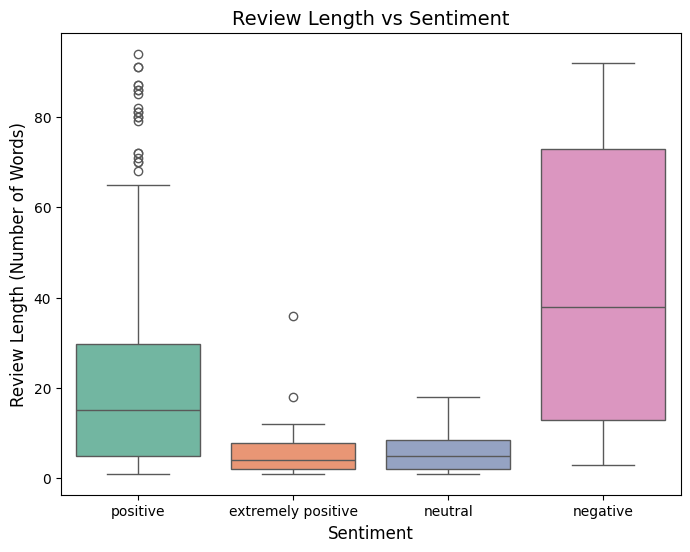

In [113]:
# Box Plot for Review Length by Sentiment
plt.figure(figsize=(8, 6))
sns.boxplot(x='Sentiment_Class', y='Review_Length', data=new_data, hue = 'Sentiment_Class', palette='Set2')
plt.title('Review Length vs Sentiment', fontsize=14)
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Review Length (Number of Words)', fontsize=12)
plt.show()


**Observation: Review Length vs Sentiment**

The boxplot shows the distribution of review lengths (in number of words) across different sentiment classes — positive, extremely positive, neutral, and negative.

**<u>Negative reviews</u>** 
Tend to be the longest on average, with a wide range extending up to around 90 words. This suggests users may write more detailed explanations when expressing dissatisfaction or negative sentiments.

**<u>Positive reviews</u>** 
Generally shorter than negative ones but longer than extremely positive and neutral reviews. The moderate length indicates that positive reviewers provide a fair amount of detail, but less so than negative reviewers.

**<u>Extremely positive reviews</u>** 
Surprisingly the shortest on average, clustered mostly below 10 words, indicating brief, highly enthusiastic comments rather than detailed feedback.

**<u>Neutral reviews</u>**
Also tend to be shorter, typically under 10 words, reflecting concise or less emotionally charged feedback.

**In summary, longer reviews are more often associated with negative sentiment, indicating that customers might write lengthier, more detailed reviews when dissatisfied. Conversely, extremely positive and neutral reviews tend to be shorter and less elaborate.**

### <span style="background-color: blue; color: white; padding: 5px; border-radius: 5px;">5. Reporting</span>

**Task:** Summarize the findings in a clear, concise report.  

#### <b>Sentiment Analysis Report: Flipkart Customer Reviews for iPhone 15 128GB</b>

## 1. Overview of the Data Collection and Cleaning Process
<u>**Data Source**</u>: Customer reviews were collected from Flipkart for the iPhone 15 128GB model through web scraping with the help of libraries like Selenium and BeautifulSoup .

<u>**Preprocessing**</u>:
  - Reviews were cleaned by removing irrelevant characters, converting cases, and unnecessary spaces.
  - Text was tokenized to standardize the input for analysis.
  - Sentiments were classified into categories (e.g., positive, extremely positive, neutral, negative, extremely negative) using sentiment analysis techniques.

## 2. Sentiment Analysis Results
<u>**Sentiment Distribution**</u>:
  - The majority of the reviews exhibit a positive sentiment, indicating overall customer satisfaction.
  - Extremely positive reviews constitute the second-largest group, reflecting strong enthusiasm from a significant subset of customers.
  - Neutral and negative sentiments represent a comparatively smaller portion of the reviews, suggesting fewer indifferent or dissatisfied customers.
      
<u>**Average Sentiment Per Rating**</u>:
  - Higher star ratings consistently corresponded with positive and extremely positive sentiments, reflecting strong customer approval.
  - Lower star ratings were predominantly linked to neutral or negative sentiments, highlighting areas of dissatisfaction within those reviews.

## 3. Insights
<u>**Positive Highlights**</u>
- Customers appreciated the **design, camera quality, and overall performance** of the iPhone 15.
- **Battery life improvements** were a common positive theme.
  
<u>**Common Issues**</u>
- Neutral and negative sentiments frequently emphasized **pricing concerns** and occasional problems related to **delivery or packaging**.
- Some reviews also reported **compatibility issues** with accessories and sporadic **software glitches**.
    
## 4. Recommendations
<u>**Product Improvements**</u>
- Address the minor software glitches reported by users to enhance product reliability.
- Investigate and resolve compatibility issues with certain accessories to ensure a seamless user experience.

<u>**Marketing Focus**</u>
- Emphasize key strengths such as **camera performance**, **battery life**, and the **sleek design** in marketing campaigns to attract potential buyers.
- Mitigate pricing concerns by promoting **EMI options**, **exchange offers**, and limited-time discounts to improve affordability and accessibility.

<u>**Operational Enhancements**</u>
- Streamline delivery processes to reduce complaints related to packaging and delays, ensuring timely and secure product arrival.
- Maintain active monitoring of **customer feedback** to promptly identify and address emerging issues, fostering customer satisfaction.

### Libraries and Tools:
- Selenium: For automating the web scraping process.

- BeautifulSoup: For parsing HTML and extracting review details.

- Pandas: For data cleaning, processing, and analysis.

- TextBlob: For performing sentiment analysis on the review text.

- Matplotlib/Seaborn: For visualizations like sentiment distribution and word clouds.